# 05 - RL Adaptive Fusion, Policy Analysis, and Ablation


> Reproducibility note: expensive training commands are shown as code or comments. For viva, these notebooks load the saved final outputs committed in the repository, so the panel can inspect the evidence without rerunning hours of training.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image

# Works in Colab and in a local clone. In Colab, uncomment the mount lines if needed.
try:
    from google.colab import drive  # type: ignore
    # drive.mount('/content/drive')
    COLAB_ROOT = Path('/content/drive/MyDrive/fake-news-rl-fusion')
    PROJECT_ROOT = COLAB_ROOT if COLAB_ROOT.exists() else Path.cwd().resolve().parent
except Exception:
    PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()

print('PROJECT_ROOT =', PROJECT_ROOT)

def read_json(relative_path):
    with open(PROJECT_ROOT / relative_path, 'r', encoding='utf-8') as f:
        return json.load(f)

def read_csv(relative_path):
    return pd.read_csv(PROJECT_ROOT / relative_path)

def show_metrics(metrics, keys=('macro_f1', 'accuracy', 'roc_auc', 'balanced_accuracy')):
    rows = []
    for key in keys:
        if key in metrics:
            rows.append({'metric': key, 'value': metrics[key]})
    display(pd.DataFrame(rows))

PROJECT_ROOT = C:\Users\acer\Documents\GitHub\fake-news-rl-fusion


## Purpose
This notebook documents the core novelty: a contextual-bandit/RL controller that selects image-text fusion weights from reliability-aware state features.

In [2]:
rl = read_json('outputs/metrics/final_rl_fusion_metrics.json')
print('Best validation macro F1:', rl.get('best_validation_macro_f1'))
print('Best checkpoint:', rl.get('best_checkpoint_path'))
show_metrics(rl['test']['metrics'])
display(pd.DataFrame([{'split': rl['test']['split'], 'rows': rl['test']['rows'], 'avg_image_weight': rl['test']['average_image_weight'], 'avg_text_weight': rl['test']['average_text_weight']}]))

Best validation macro F1: 0.8677406707239413
Best checkpoint: outputs/checkpoints/final_fusion/best_fusion_q_network.pt


,metric,value
0,macro_f1,0.867604
1,accuracy,0.867725
2,roc_auc,0.932894
3,balanced_accuracy,0.868248


,split,rows,avg_image_weight,avg_text_weight
0,test,3780,0.659444,0.340556


,epoch,epsilon,train_loss,train_mean_reward,validation_macro_f1
40,41,0.224490,0.034927,0.962526,0.859109
41,42,0.205102,0.035148,0.962949,0.857542
42,43,0.185714,0.033868,0.964431,0.859117
43,44,0.166327,0.032547,0.969513,0.858056
44,45,0.146939,0.033775,0.967395,0.858590
45,46,0.127551,0.032294,0.970995,0.858588
46,47,0.108163,0.032132,0.970465,0.861486
47,48,0.088776,0.032530,0.973112,0.859650
48,49,0.069388,0.031660,0.974488,0.858070
49,50,0.050000,0.031785,0.976182,0.858068


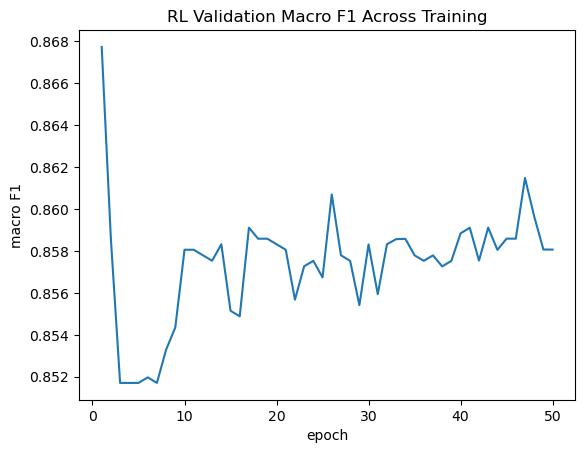

In [3]:
history_rows = []
for row in rl.get('history', []):
    history_rows.append({'epoch': row['epoch'], 'epsilon': row['epsilon'], 'train_loss': row['train_loss'], 'train_mean_reward': row['train_mean_reward'], 'validation_macro_f1': row['validation_metrics']['macro_f1']})
history = pd.DataFrame(history_rows)
display(history.tail(10))
ax = history.plot(x='epoch', y='validation_macro_f1', title='RL Validation Macro F1 Across Training', legend=False)
ax.set_ylabel('macro F1')
plt.show()

,action,count
0,0,771
1,1,1072
2,2,465
3,3,1279
4,4,187
5,5,6


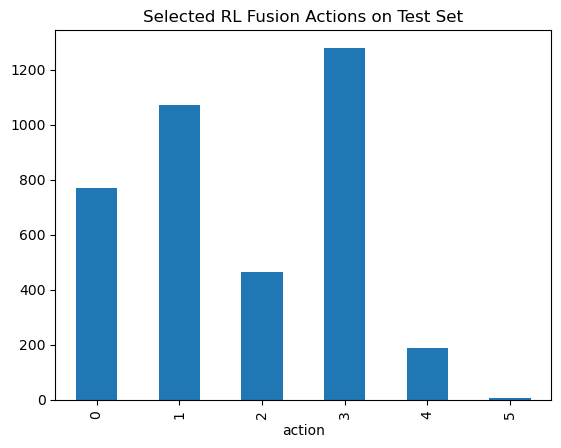

Average weights: {'average_image_weight': 0.6594444444444444, 'average_text_weight': 0.34055555555555556, 'image_weight_std': 0.1635889102893776, 'text_weight_std': 0.16358891028937653}
Oracle upper-bound macro F1: 0.9306107315006091


In [4]:
policy = read_json('outputs/metrics/final_rl_policy_analysis.json')
actions = pd.Series(policy['action_distribution'], name='count').rename_axis('action').reset_index()
display(actions)
actions.plot.bar(x='action', y='count', legend=False, title='Selected RL Fusion Actions on Test Set')
plt.show()
print('Average weights:', policy['weight_summary'])
print('Oracle upper-bound macro F1:', policy['oracle_action_upper_bound']['metrics']['macro_f1'])

,name,state_dim,features,best_validation_macro_f1,test_macro_f1,test_accuracy,test_roc_auc,average_image_weight,average_text_weight
0,full_reliability_state,9,"image_probability,image_confidence,image_quali...",0.867479,0.867333,0.867460,0.932643,0.583069,0.416931
1,prediction_confidence,4,"image_probability,image_confidence,text_probab...",0.863345,0.858994,0.858995,0.918426,0.446058,0.553942
2,probabilities_only,2,"image_probability,text_probability",0.860701,0.852315,0.852381,0.920512,0.639656,0.360344


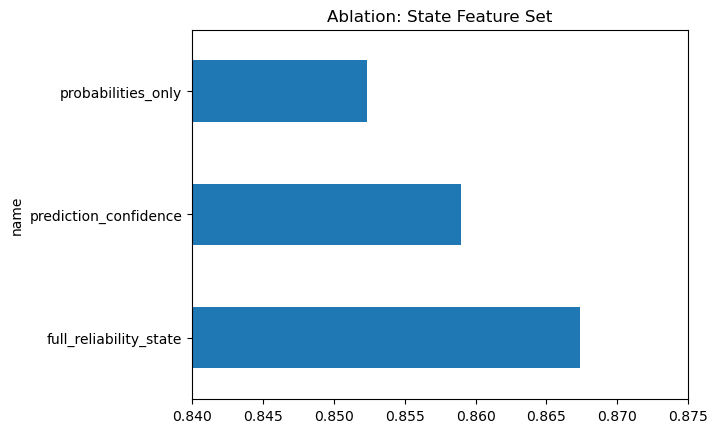

In [5]:
ablation = read_csv('outputs/metrics/final_ablation_summary.csv').sort_values('test_macro_f1', ascending=False)
display(ablation)
ablation.plot.barh(x='name', y='test_macro_f1', legend=False, title='Ablation: State Feature Set')
plt.xlim(0.84, 0.875)
plt.show()

In [6]:
# Reproduction commands:
# %cd /content/drive/MyDrive/fake-news-rl-fusion
# !python scripts/train_rl_fusion.py --config configs/final_fusion.yaml
# !python scripts/analyze_rl_policy.py --config configs/final_rl_analysis.yaml
# !python scripts/run_ablation.py --config configs/final_ablation.yaml

## Viva Note
The ablation is important: probabilities-only and confidence-only states are weaker than the full reliability state. This supports the design choice to include quality, disagreement, confidence difference, and quality difference.